In [1]:
#Imports
import sys,os
os.environ['MKL_NUM_THREADS'] = '4' # set number of MKL threads to run in parallel
from quspin.operators import hamiltonian,quantum_operator
from quspin.basis import spin_basis_1d
from numpy.random import uniform,seed
from joblib import delayed,Parallel

from itertools import combinations
from functools import partial
import numpy as np
import gc
import pickle
from time import time
from quspin.tools.measurements import diag_ensemble
from quspin.tools.evolution import ED_state_vs_time
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot, show, figure, xlabel, ylabel, xscale, yscale, legend, loglog,title,show,imshow,colorbar,legend,scatter
from numpy import pi, exp, log, sin , cos, tan, log, array
import quspin
timestamp = time()
from scipy.optimize import minimize_scalar

# dat and alphasearch already defined



In [2]:
###Functions
def timer(timestamp):
    #Timer Function
    print("time =", time()-timestamp)
    return

def fin_string(ns,s): #ns = length of string s = operator
    #Max string length
    if ns>L:
        ns=L
    else:
        pass
    
    
    def linears(start,m):
        #Find all indices in string
        ind=[i%L for i in range(start,start+ns)]
     #All combinations
        perm=list(combinations(ind,m))
      #Add each coupling to operator
        for j in range(len(perm)):
#            S_temp=[((-1)**m)*(2**m)/(L*(2**ns))] ########### Down #
            S_temp=[1/(L*(2**ns))] ###################### Up
            for i in range(len(perm[j])):
                S_temp.append(perm[j][i])
        ##Saving Couplin gs lists
            if j==0: 
                S_temp_2=[S_temp]
            else: 
                S_temp_2.append(S_temp)
        return S_temp_2
    #List to store orders of interaction
    o_type=np.empty(ns,dtype=object)
    
    for i in range(ns):
        #ex: "z"*2= "zz"
        o_type[i]=s*(i+1)

    #Iterate over each Site
    for k in range(L):
        #Iterate over different string lengths
      for i in range(ns):
          #First item defines list
          if k==0 and i==0:
              #example: i = 0 operator_list = [['x', linears(k,1)]]
              operator_list=[[o_type[i],linears(k,i+1)]]
          else:
              operator_list.append([o_type[i],linears(k,i+1)])
    S_temp_1 = [[(1/((ns*2**ns))), i] for i in range(ns)]
    #S_temp_1 = [[(1/((ns*2**(ns)))), 1] ]
    operator_list.append(["I",S_temp_1])
    operator_dict=dict(S=operator_list)
    O = quantum_operator(operator_dict,basis=basis,check_symm=False,check_herm=False)
    return array(O.todense())

def commute(A,B):
    return A@B-B@A
def diagonalize(op,basis):
    return basis.T@op@basis
def norm(op):
    return np.abs(op)/np.max(np.abs(op))

In [3]:
###### Model parameters
#Length of chain
L = 8
#X field
J1 = 1 #NN term 
J2 = 0
h0 = 0
###Using Quantum_Operator to build hamitlonian 
basis = spin_basis_1d(L, pauli = -1)
#NN Sigma x term (Periodic Boundary Conditions)
NN_sigma_x = [ [-J1, i, (i+1)%L] for i in range(L)]
NNN_sigma_x = [ [-J2, i, (i+1)%L] for i in range(L)]

#site coupling lists
sigma_z = [ [-1, i] for i in range(L)]
#Define the static H (that doesn't change)
static_H = [ ["xx", NN_sigma_x], ["xx",NNN_sigma_x] ] 
#The z field is the quench
Quenching_H = [["z", sigma_z]]
#Define operator dictionary
operator_dict = dict(H0= static_H, Quench = Quenching_H)
#Build Hamiltonian
H = quantum_operator(operator_dict, basis=basis, check_herm= False, check_symm = False)
#Define Parameters
params_dict = dict( H0=1, Quench=h0)
#Build H0
H1 = H.tohamiltonian(params_dict)
#Find eigenvalues
E1,V1 = np.linalg.eigh(H1.todense())
#Convert matrix to array
V = np.array(V1)
H = array(H1.todense())
E = E1

In [4]:
single_site = [ [-1, i] for i in range(L)]
z_single_site = [["z", single_site]]
operator_dict=dict(S=z_single_site)
partialH= quantum_operator(operator_dict,basis=basis,check_symm=False,check_herm=False)
partialH = array(partialH.todense())



In [5]:
#making OL
#Ex: l = 1 -> XY
#l = 2 XZY

l = 2
s=1

def sites_list(l,L):
    sites = [[1]+[(s+i)%L for i in range(l+1)] for s in range(L)]
    return sites
def string_list(l):
    string = ""
    for i in range(l):
        if i==0:
            string  += "x"
        else:
            string+="z"
    string+="y"
    return string, string[::-1]

def O(l,L,M):
    sites = sites_list(l,L)
    strings = string_list(l)
    terms = [[strings[0],sites],[strings[1],sites]]
    operator_dict=dict(S=terms)
    O= quantum_operator(operator_dict,basis=basis,check_symm=False,check_herm=False)
    O = array(O.todense())
    k = np.linspace(0,2*pi,L)
    alpha = (-1/4/(M+1))*np.sum( sin(k)*sin(k*l)/( (cos(k)-h0+0.00001)**2+sin(k)**2   ))
    return O*alpha



In [117]:
print(np.abs(A[-2]))

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


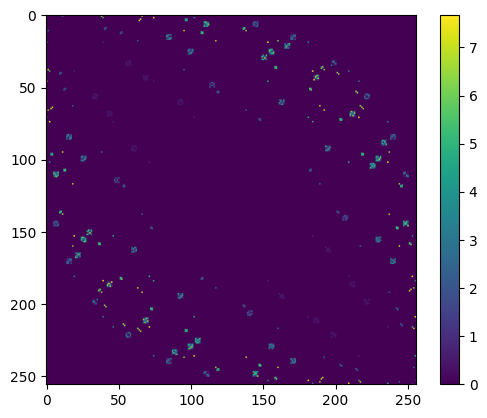

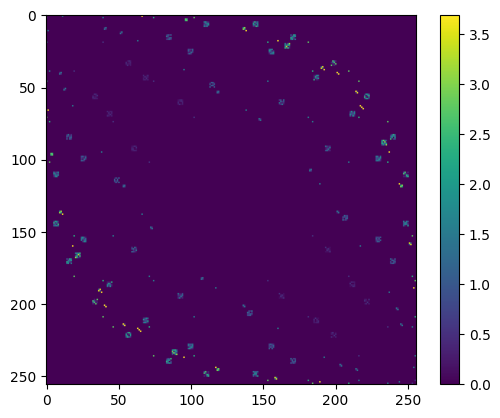

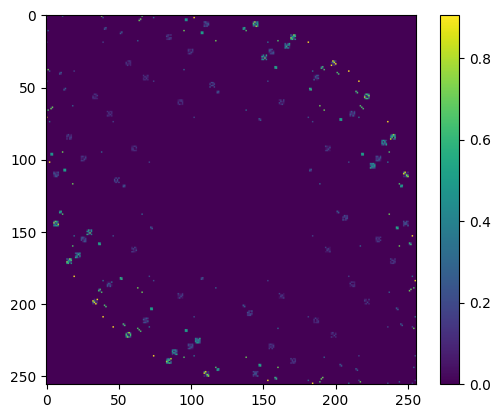

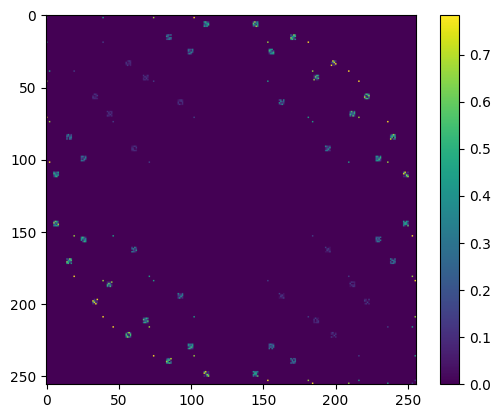

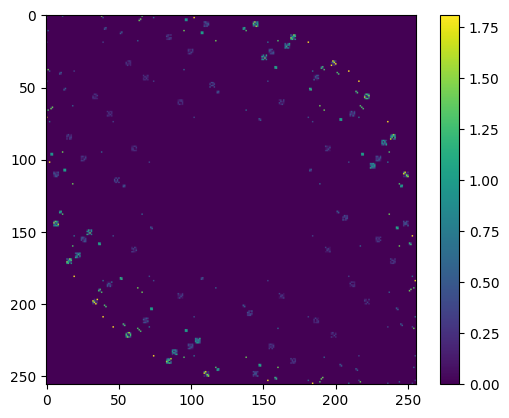

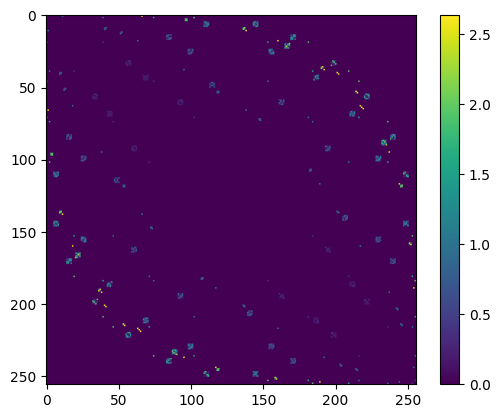

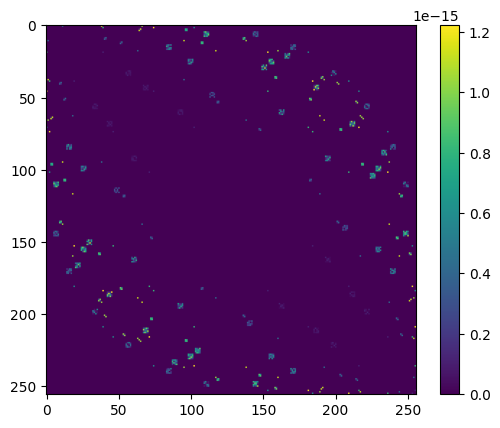

In [106]:
A= [sum([O(li,L,l) for li in np.arange(1,l+1)]) for l in range(1,L)]
A= [O(l,L,l) for l in range(1,L)]

for a in A:
    plt.imshow(np.abs(V.T@commute(a,H)@V))
    colorbar()
    show()


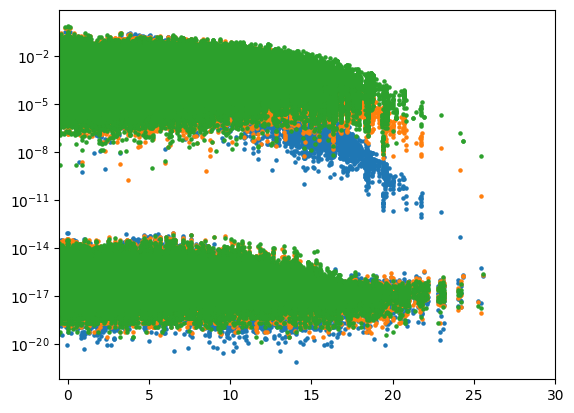

In [75]:
P=fin_string(2,"x")
dE = E[:,None]- E[None,:]
dE = dE.ravel()
Comm = commute(P,A[0])
scatter(dE,np.abs(V.T@Comm@V).ravel(),s=5)

P=fin_string(4,"x")
Comm = commute(P,A[0])

scatter(dE,np.abs(V.T@Comm@V).ravel(),s=5)
P=fin_string(5,"x")
Comm = commute(P,A[0])


scatter(dE,np.abs(V.T@Comm@V).ravel(),s=5)
plt.xlim(-.5,30)

yscale("log")

KeyboardInterrupt: 

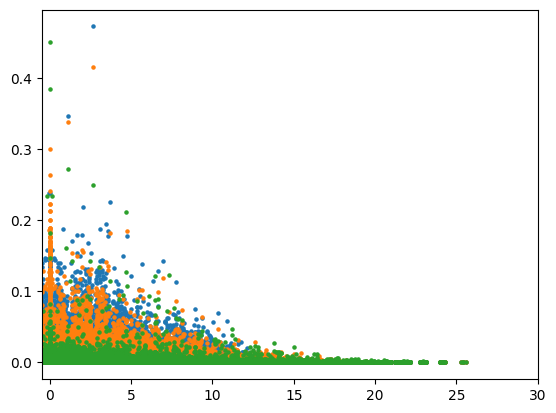

In [76]:
j = -1
P=fin_string(2,"x")
dE = E[:,None]- E[None,:]
dE = dE.ravel()
Comm = commute(P,A[j])
scatter(dE,np.abs(V.T@Comm@V).ravel(),s=5)

P=fin_string(4,"x")
Comm = commute(P,A[j])

scatter(dE,np.abs(V.T@Comm@V).ravel(),s=5)
P=fin_string(8,"x")
Comm = commute(P,A[j])

scatter(dE,np.abs(V.T@Comm@V).ravel(),s=5)
plt.xlim(-.5,30)
P=fin_string(10,"x")
Comm = commute(P,A[j])

scatter(dE,np.abs(V.T@Comm@V).ravel(),s=5)
plt.xlim(-.5,30)

yscale("log")

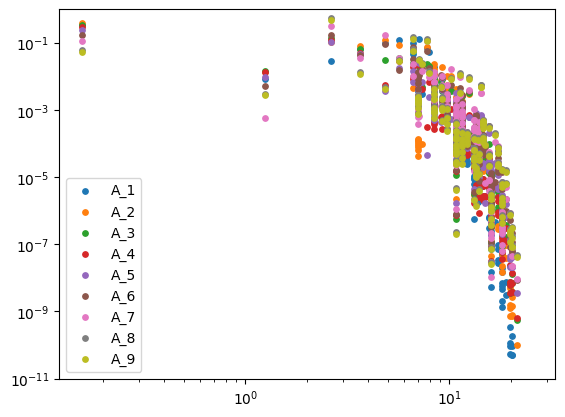

In [77]:
j = 0
P=fin_string(2,"x")
dE = E[:,None]- E[None,:]
dE = dE[:,0].ravel()
for j,a in enumerate(A):
    Comm = commute(P,a)
    scatter(dE,np.abs(V.T@Comm@V)[:,0].ravel(),s=15,label=f"A_{j+1}")
legend()
#plt.xlim(-.5,30)
plt.ylim(10e-12,1)
yscale("log")
xscale("log")

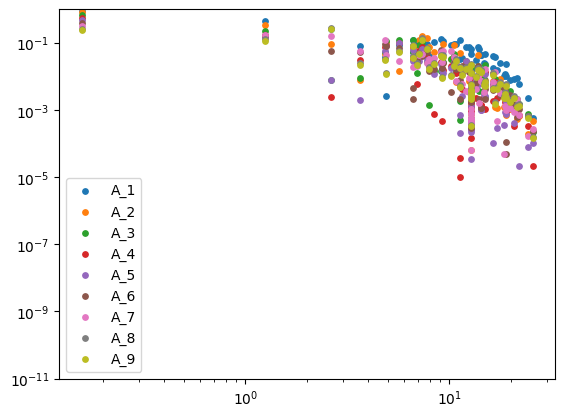

In [78]:
j = 0
P=fin_string(8,"x")
dE = E[:,None]- E[None,:]
dE = dE[:,0].ravel()
for j,a in enumerate(A):
    Comm = commute(P,a)
    scatter(dE,np.abs(V.T@Comm@V)[:,0].ravel(),s=15,label=f"A_{j+1}")
legend()
#plt.xlim(-.5,30)
plt.ylim(10e-12,1)
yscale("log")
xscale("log")

In [79]:
def flobenius(O):
    return np.sum(np.abs(O)**2)

In [80]:

a = A[0]
ns = np.arange(1,11)
P = [ fin_string(n,"x") for n in ns]


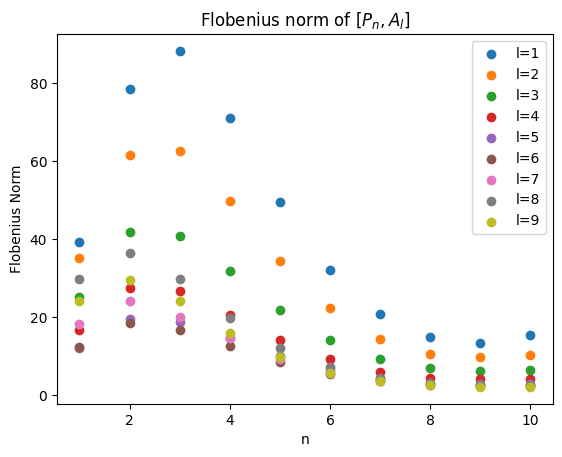

In [81]:
for j, a in enumerate(A):
    dat=[]

    for p,n in zip(P,ns):
        
        dat.append(flobenius(commute(p,a)))

    scatter(ns,dat,label=f"l={j+1}")
    xlabel("n")
    ylabel("Flobenius Norm")
    title(r"Flobenius norm of $[P_n,A_l]$")
    legend()